# 00. 채점 함수 분석 (Step 0, 2)

계획서의 Step 0과 2단계에 해당함. 데이터보다 **점수 구조**를 먼저 봄.

1. label 분포
2. 가중치 행렬
3. 기준 전략과 oracle 전략의 점수
4. 점수를 어디서 잃는지 (정답 클래스별 벌점 기여)
5. 정답이 보합인 행의 예측도 점수를 바꾸는가
6. 크기(M)와 방향(D)으로 분해

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import eda_utils as U

U.setup_plot()
pd.set_option("display.float_format", "{:.4f}".format)

panel = U.cached("panel_dev", U.build_panel)     # 첫 실행 약 3초, 이후 캐시
print(panel.shape, panel["target"].min().date(), "~", panel["target"].max().date())

(26100, 33) 2024-08-14 ~ 2026-09-14


## 1. label 분포

### 그림: 막대그래프 (bar chart)
막대그래프는 **범주마다 값 하나를 막대의 길이로 나타낸 그림**임. 가로축은 범주(여기서는 label 0~4),
세로축은 그 범주의 크기(비율)임. 막대끼리 길이를 비교해서 어느 범주가 많고 적은지를 한눈에 봄.

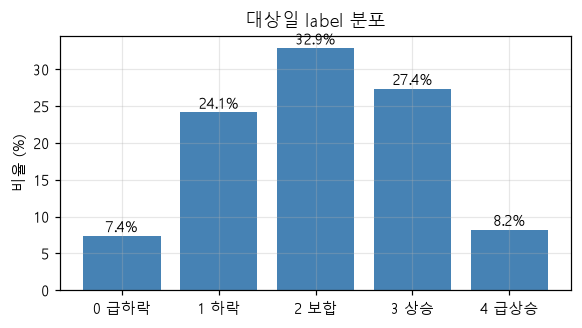

In [2]:
dist = panel["label"].value_counts(normalize=True).sort_index()
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar([f"{i} {n}" for i, n in enumerate(U.LABELS)], dist.values * 100, color="steelblue")
for i, v in enumerate(dist.values * 100):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center")
ax.set(title="대상일 label 분포", ylabel="비율 (%)")
plt.show()

## 2. 가중치 행렬

### 그림: 히트맵 (heatmap)
히트맵은 **행과 열로 된 표의 각 칸을 값의 크기에 따라 색으로 칠한 그림**임. 색이 진할수록 값이 큼.
숫자 표만 보면 큰 칸을 찾기 어렵지만, 히트맵은 큰 값이 어디 몰려 있는지 바로 보여 줌.
여기서는 행이 정답, 열이 예측이고, 칸의 값은 그렇게 틀렸을 때 받는 벌점 가중치 w_ij 임.

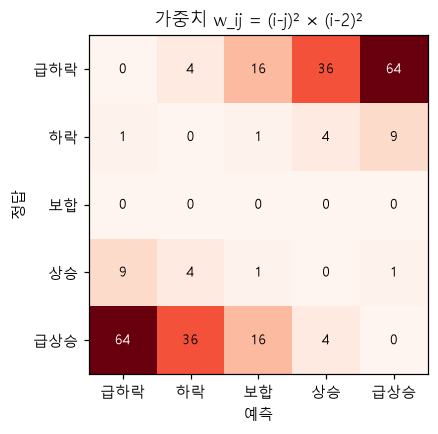

In [3]:
W = pd.DataFrame(U.WEIGHT, index=U.LABELS, columns=U.LABELS)
fig, ax = plt.subplots(figsize=(5, 4))
U.plot_heatmap(ax, W, "가중치 w_ij = (i-j)² × (i-2)²", cmap="Reds")
plt.show()

- 정답이 보합(2)인 행은 전부 0임.
- 급하락 ↔ 급상승(64)이 급등락을 놓치는 경우(0→1, 4)보다 16배 무거움.
  그래서 recall보다 **반대로 찍지 않는 것**이 먼저임.

## 3. 기준 전략과 oracle 전략

oracle은 정답을 일부 안다고 가정한 상한 실험임. 모델에는 쓰지 않음.
`score_ext`는 과제 지표에 `flip_rate`(급등락을 반대로 찍은 비율)와 `loss_c*`(정답 클래스별 벌점 기여)를 더해 보여 줌.

In [4]:
preds = U.baseline_preds(panel["label"])
table = pd.DataFrame({k: U.score_ext(panel["label"], v) for k, v in preds.items()}).T
table[["score", "accuracy", "direction", "big_recall", "big_prec", "flip_rate"]]

,score,accuracy,direction,big_recall,big_prec,flip_rate
전부 보합,0.0000,0.3286,0.0000,0.0000,NaN,0.0000
전부 급상승,0.0000,0.0823,0.5304,0.5271,0.0823,1.0000
무작위 (정답 분포대로),-0.0004,0.2545,0.3384,0.0763,0.0770,0.1564
방향만 oracle,0.8343,0.8438,1.0000,0.0000,NaN,0.0000
"급등락만 oracle, 나머지 보합",0.8616,0.4848,0.2327,1.0000,1.0000,0.0000
"급등락을 반대로, 나머지 보합",-1.8182,0.3286,0.0000,0.0000,0.0000,2.0000
전부 맞힘,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000


## 4. 점수를 어디서 잃는가

### 그림: 누적 가로 막대그래프 (stacked bar chart)
누적 막대그래프는 **막대 하나를 여러 조각으로 나눠, 전체가 어떤 부분들의 합으로 이뤄졌는지 보여 주는 그림**임.
막대 전체 길이는 합계이고, 색깔별 조각 길이는 각 부분의 크기임.

여기서 막대 전체 길이는 Σw·O / Σw·E = 1 − score, 즉 **잃은 점수**임.
조각은 정답 클래스(급하락, 하락, 상승, 급상승)별로 잃은 몫임. 보합은 가중치가 0이라 조각이 없음.

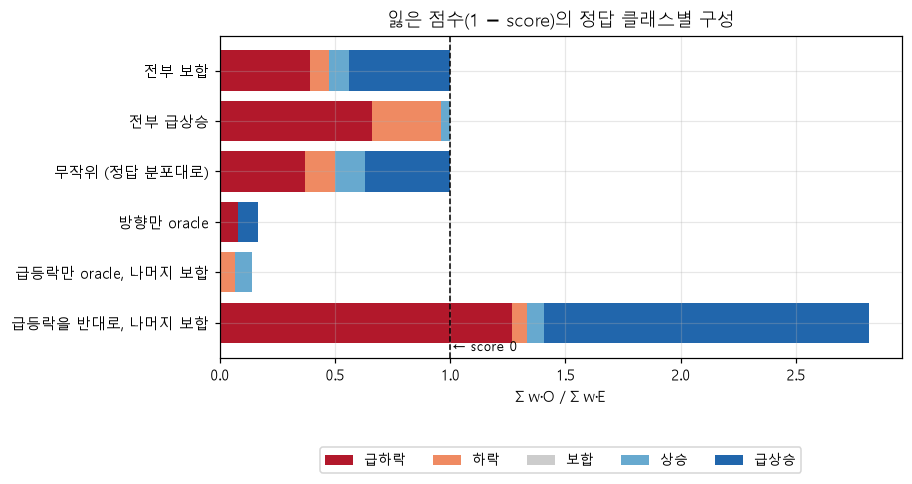

In [5]:
loss = table[[f"loss_c{i}" for i in range(5)]].drop(index="전부 맞힘")
loss.columns = U.LABELS
fig, ax = plt.subplots(figsize=(8, 3.8))
left = np.zeros(len(loss))
for c, col in zip(["#b2182b", "#ef8a62", "#cccccc", "#67a9cf", "#2166ac"], U.LABELS):
    ax.barh(loss.index, loss[col], left=left, color=c, label=col)
    left += loss[col].to_numpy()
ax.axvline(1, color="k", lw=1, ls="--")
ax.text(1.01, 0.02, "← score 0", transform=ax.get_xaxis_transform(), fontsize=9)
ax.set(title="잃은 점수(1 − score)의 정답 클래스별 구성", xlabel="Σ w·O / Σ w·E")
ax.legend(ncol=5, loc="lower center", bbox_to_anchor=(0.5, -0.38), fontsize=9)
ax.invert_yaxis()
plt.show()

## 5. 정답이 보합인 행의 예측도 점수를 바꾸는가

### 그림: 선 그래프 (line chart)
선 그래프는 **가로축의 값이 변할 때 세로축의 값이 어떻게 따라 변하는지를 점을 이어 보여 주는 그림**임.
기울기로 변화의 방향과 크기를 읽음.

실험은 이렇게 함. "급등락만 oracle" 예측에서 **정답이 보합인 행** 중 일부만 급상승(4)으로 바꿈.
이 행들은 가중치가 0이라 분자(Σw·O)는 그대로임. 그런데 예측 분포가 바뀌면서 분모(Σw·E)가 변하면 점수도 변함.

,frac,score,num,denom
0,0.0000,0.8616,13446.0000,97180.6523
1,0.0500,0.8641,13446.0000,98961.0011
2,0.1000,0.8665,13446.0000,100745.5096
3,0.2000,0.8711,13446.0000,104314.5266
4,0.4000,0.8794,13446.0000,111448.4009


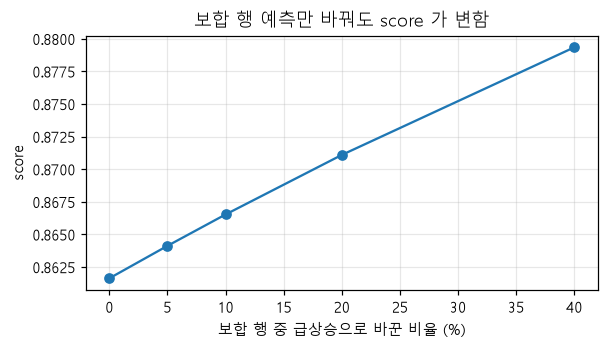

In [6]:
eff = U.flat_row_effect(panel["label"], preds["급등락만 oracle, 나머지 보합"])
display(eff)
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(eff["frac"] * 100, eff["score"], marker="o")
ax.set(title="보합 행 예측만 바꿔도 score 가 변함", xlabel="보합 행 중 급상승으로 바꾼 비율 (%)", ylabel="score")
plt.show()

## 6. 크기(M)와 방향(D)으로 분해

- M = 1[label ∈ {0, 4}] : 급등락 여부
- D = sign(수익률) : 방향

### 그림: 정렬된 가로 막대그래프
종목을 값 순서로 정렬해서 막대를 그리면 **분포가 얼마나 치우쳐 있는지**가 보임.
위아래 끝의 막대 길이 차이가 크면 종목 간 편차가 큰 것임.

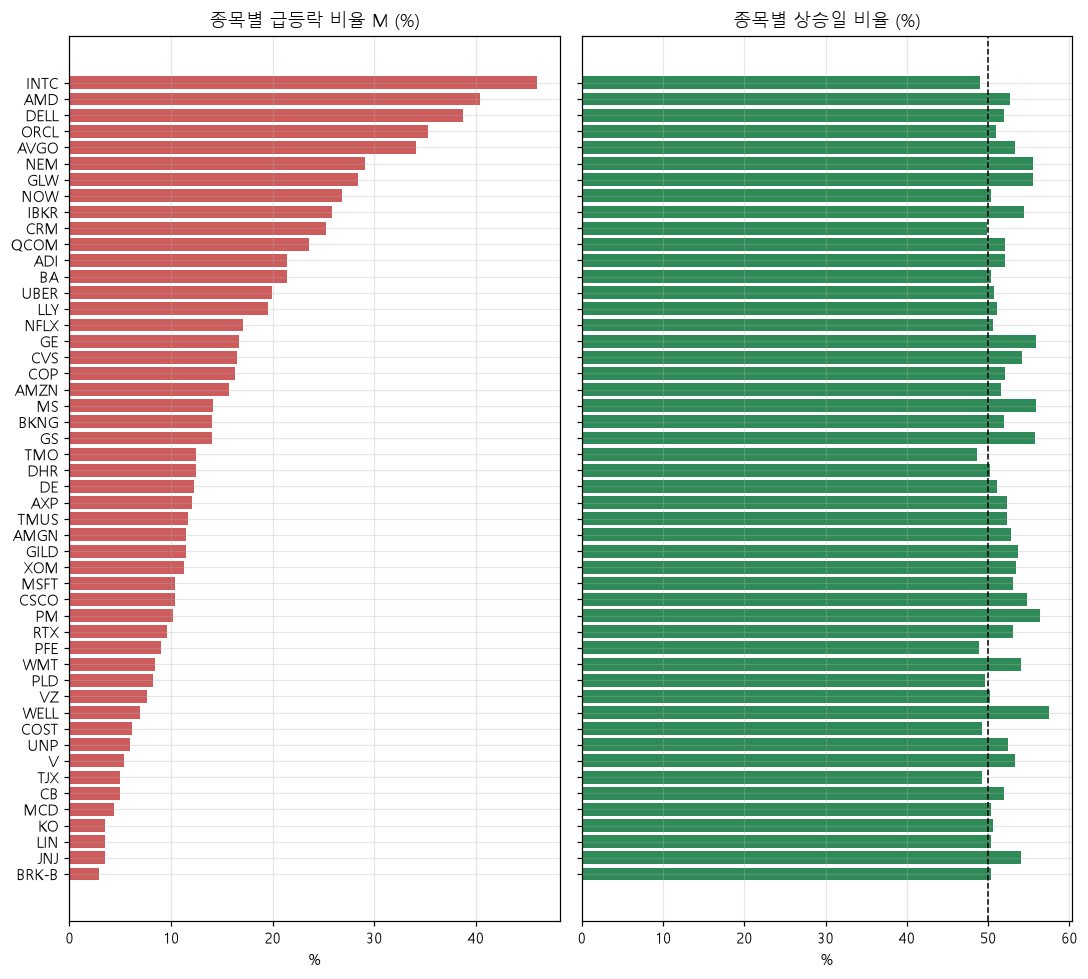

In [7]:
by_sym = panel.groupby("symbol").agg(M=("M", "mean"), up=("D", lambda d: (d > 0).mean()),
                                     vol20=("vol20", "mean")).sort_values("M")
fig, axes = plt.subplots(1, 2, figsize=(10, 9), sharey=True)
axes[0].barh(by_sym.index, by_sym["M"] * 100, color="indianred")
axes[0].set(title="종목별 급등락 비율 M (%)", xlabel="%")
axes[1].barh(by_sym.index, by_sym["up"] * 100, color="seagreen")
axes[1].axvline(50, color="k", lw=1, ls="--")
axes[1].set(title="종목별 상승일 비율 (%)", xlabel="%")
plt.tight_layout()
plt.show()

크기(M)는 종목 간 편차가 매우 크고, 방향(상승일 비율)은 대부분 50% 근처에 모여 있음.
즉 **크기는 종목 특성으로 상당 부분 예측되고, 방향은 그렇지 않음**.
01 노트북에서 크기는 변동성으로, 방향은 갭으로 설명되는지 봄.